<a href="https://colab.research.google.com/github/nandanarahana-gif/aiml-project/blob/main/AIML2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset:
    Hours_Studied  Attendance  Previous_Score  Final_Score
0              1          60              50           52
1              2          65              55           57
2              3          70              60           63
3              4          75              65           67
4              5          80              70           72
5              6          85              75           78
6              7          90              80           83
7              8          92              85           88
8              9          95              90           92
9             10          98              95           97

Evaluation Results:
MAE: 0.28
MSE: 0.09
RMSE: 0.3
R² Score: 1.0


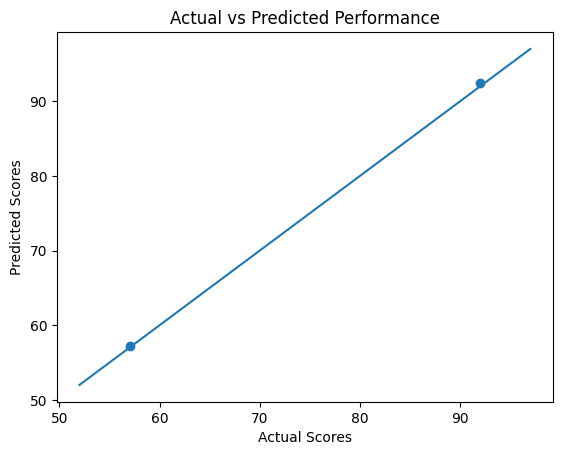


Model Coefficients:
Hours_Studied : 0.16
Attendance : 0.17
Previous_Score : 0.82
Intercept: 0.27

Predicted score: 87.06


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [1]:
# ============================================
# STUDENT PERFORMANCE PREDICTION USING LINEAR REGRESSION
# ============================================

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================
# Step 2: Create Dataset (No file needed)
# ============================================

data = pd.DataFrame({
    'Hours_Studied': [1,2,3,4,5,6,7,8,9,10],
    'Attendance': [60,65,70,75,80,85,90,92,95,98],
    'Previous_Score': [50,55,60,65,70,75,80,85,90,95],
    'Final_Score': [52,57,63,67,72,78,83,88,92,97]
})

print("Dataset:\n", data)

# ============================================
# Step 3: Define Features & Target
# ============================================

X = data[['Hours_Studied', 'Attendance', 'Previous_Score']]
y = data['Final_Score']

# ============================================
# Step 4: Split Data
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================
# Step 5: Train Model
# ============================================

model = LinearRegression()
model.fit(X_train, y_train)

# ============================================
# Step 6: Prediction
# ============================================

y_pred = model.predict(X_test)

# ============================================
# Step 7: Evaluation Metrics
# ============================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nEvaluation Results:")
print("MAE:", round(mae, 2))
print("MSE:", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 2))

# ============================================
# Step 8: Visualization (Actual vs Predicted)
# ============================================

plt.figure()

plt.scatter(y_test, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()])

plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted Performance")

plt.show()

# ============================================
# Step 9: Model Coefficients
# ============================================

print("\nModel Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(feature, ":", round(coef, 2))

print("Intercept:", round(model.intercept_, 2))

# ============================================
# Step 10: Predict New Student
# ============================================

new_student = np.array([[7, 90, 85]])
predicted = model.predict(new_student)

print("\nPredicted score:", round(predicted[0], 2))